# <span style="color:darkblue;">[LDATS2350] - DATA MINING</span>

### <span style="color:darkred;">Python06 - Handling Imbalanced Datasets</span>

**Prof. Olivier Caelen**  

<br/>

**<span style="color:darkgreen;">Kenrick So</span>** (<span style="color:gray;">kenrick.so@uclouvain.be</span>)

---

## **Objective**

In this session, we will learn techniques to handle **imbalanced datasets**, where one class significantly outweighs others. Imbalanced datasets are common in real-world applications such as fraud detection, medical diagnoses, and customer churn prediction. Without addressing this imbalance, machine learning models tend to be biased toward the majority class, leading to poor performance on the minority class.

---

### **Techniques Covered**

1. **Understanding the Problem**:
   - Identify imbalance in the dataset using descriptive statistics and visualization.

2. **Resampling Techniques**:
   - **Oversampling**: Increase the number of samples in the minority class.
   - **Undersampling**: Decrease the number of samples in the majority class.

3. **Synthetic Techniques**:
   - Use methods like **SMOTE (Synthetic Minority Oversampling Technique)** to create synthetic samples for the minority class.

4. **Evaluation Metrics**:
   - Use metrics like **precision**, **recall**, **F1-score**, and **ROC-AUC** to assess performance.

5. **Weighted Algorithms**:
   - Adjust weights in machine learning algorithms to balance the importance of each class.

---

In [1]:
import pandas as pd
df = pd.read_csv('../Data/diabetes.csv')
df.head()

,timespreg,gluctol,diaspb,triceps,insulin,massindex,pedigree,age,target
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Exploring Class Distribution in a Dataset**

#### **Objective**
Understand the **class distribution** in a dataset using **Pandas** for frequency counts and **Seaborn** for visualization. This exercise will help you identify whether your dataset is imbalanced.

---

#### **Instructions**

1. **Inspect Class Frequencies**:
   - Use `groupby()` and `size()` from Pandas to calculate the frequency of each class in the target variable.

2. **Visualize Class Counts**:
   - Use Seaborn's `countplot()` to create a bar chart showing the distribution of classes in the target variable.
   - Label the axes appropriately for better understanding.

3. **Customize the Plot**:
   - Apply a predefined Seaborn style or Matplotlib style (e.g., `"ggplot"`) to enhance the plot's appearance.


</div>



In [2]:
print(df.groupby('target').size()) #"target" is the name of the target column, change it accordingly to your dataset

target
0    500
1    268
dtype: int64


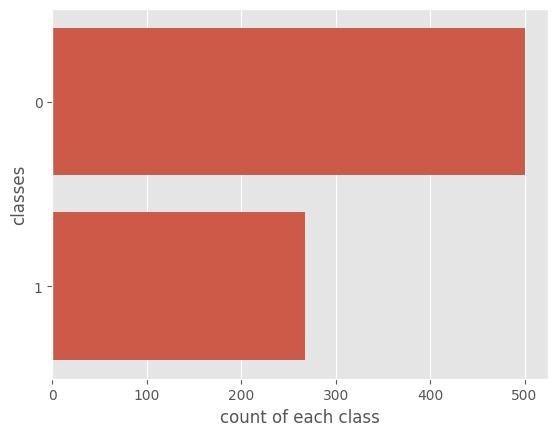

In [3]:
#some imports to plot 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

#Visualize Class Counts
sns.countplot(y=df.target ,data=df) #"target" is the name of the target column, change it accordingly to your dataset
plt.xlabel("count of each class")
plt.ylabel("classes")
plt.show()

**Expected output**

<img src="imbalaced_data.png" />

<div style="border: 2px solid darkblue; padding: 10px; background-color: #89D9F5;">

### **Exercise - Evaluating Model Accuracy with `accuracy_score`**

#### **Objective**
Learn how to calculate the **accuracy** of a model's predictions using Scikit-Learn's `accuracy_score`. This exercise demonstrates how accuracy is computed and helps you interpret the metric when dealing with imbalanced datasets.

In [4]:
import numpy as np
from sklearn.metrics import accuracy_score

y = df["target"]

# Step 3: Generate baseline predictions (all zeros)
y_pred = np.zeros(len(y))  # Predicting all samples as 0

# Step 4: Calculate accuracy
accuracy = accuracy_score(y, y_pred)
print(f"Accuracy of baseline model: {accuracy:.2f}")


Accuracy of baseline model: 0.65


## Downsampling

In [5]:
from sklearn.utils import resample

#Down-sample Majority Class
#1) Separate majority and minority classes
df_majority = df[df.target==0] #"target" is the name of the target column, change it accordingly to your dataset
df_minority = df[df.target==1] #"target" is the name of the target column, change it accordingly to your dataset
 
#2) Downsample majority class
df_majority_downsampled = resample(df_majority, 
                                   replace=False,
                                   n_samples=268,     # number of samples into the minority class (change it accordingly to your dataset)
                                   random_state=123)  # reproducible results
 
#3) Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])
 
#4) Display new class counts
df_downsampled.target.value_counts() #"target" is the name of the target column, change it accordingly to your dataset

target
0    268
1    268
Name: count, dtype: int64

## Oversampling

In [6]:
from sklearn.utils import resample

#Over-sample Minority Class
#1) Separate majority and minority classes
df_majority = df[df.target==0] #"target" is the name of the target column, change it accordingly to your dataset
df_minority = df[df.target==1] #"target" is the name of the target column, change it accordingly to your dataset
 
#2) Oversample minority class
df_minority_oversampled = resample(df_minority, 
                                   replace=True,
                                   n_samples=500,     # number of samples into the minority class (change it accordingly to your dataset)
                                   random_state=123)  # reproducible results
 
#3) Combine oversampled minority class with majority class
df_oversampled = pd.concat([df_minority_oversampled, df_majority])
 
#4) Display new class counts
df_oversampled.target.value_counts() #"target" is the name of the target column, change it accordingly to your dataset

target
1    500
0    500
Name: count, dtype: int64